In [1]:
import torch
assert torch.cuda.is_available(), "No GPU detected - switch to GPU runtime in Colab"
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

!pip install -q "transformers" "datasets" "accelerate"

import os, time, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score)
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import TensorDataset, DataLoader
from transformers import (BertTokenizer, BertForSequenceClassification,
                          get_linear_schedule_with_warmup)
from torch.optim import AdamW

RANDOM_STATE = 42
MAX_LEN      = 128
BATCH_SIZE   = 32
EPOCHS       = 3
LR           = 2e-5
WEIGHT_DECAY = 0.01
GRAD_CLIP    = 1.0
MODEL_NAME   = "bert-base-uncased"
LABEL_MAP    = {"negative": 0, "neutral": 1, "positive": 2}
LABEL_NAMES  = ["negative", "neutral", "positive"]

np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
torch.cuda.manual_seed_all(RANDOM_STATE)
device = torch.device("cuda")

print(f"model={MODEL_NAME} | MAX_LEN={MAX_LEN} | batch={BATCH_SIZE} | epochs={EPOCHS}")

GPU: Tesla T4
VRAM: 14.6 GB
model=bert-base-uncased | MAX_LEN=128 | batch=32 | epochs=3


In [2]:
from google.colab import drive
drive.mount("/content/drive")

DATA_PATH  = "/content/drive/MyDrive/cfpb_pipeline/data/processed/clustered_data.csv"
MODEL_DIR  = "/content/drive/MyDrive/cfpb_pipeline/models/bert_sentiment"
PRED_PATH  = "/content/drive/MyDrive/cfpb_pipeline/outputs/predictions/sentiment_predictions.csv"
FIG_DIR    = "/content/drive/MyDrive/cfpb_pipeline/outputs/figures"

for d in [MODEL_DIR, os.path.dirname(PRED_PATH), FIG_DIR]:
    os.makedirs(d, exist_ok=True)

df = pd.read_csv(DATA_PATH)
df["label"] = df["sentiment"].map(LABEL_MAP)
print(f"Loaded: {df.shape} | label counts: {dict(df['sentiment'].value_counts())}")

Mounted at /content/drive
Loaded: (19997, 15) | label counts: {'negative': np.int64(10308), 'positive': np.int64(8899), 'neutral': np.int64(790)}


In [3]:
texts  = df["text_clean"].values
labels = df["label"].values

train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    texts, labels, test_size=0.30, stratify=labels, random_state=RANDOM_STATE
)
val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.50, stratify=temp_labels, random_state=RANDOM_STATE
)

print(f"Train: {len(train_texts):,} | Val: {len(val_texts):,} | Test: {len(test_texts):,}")
for name, arr in [("Train", train_labels), ("Val", val_labels), ("Test", test_labels)]:
    counts = np.bincount(arr, minlength=3)
    pcts   = counts / counts.sum() * 100
    print(f"{name}: " + " ".join(f"{LABEL_NAMES[i]}={counts[i]:,} ({pcts[i]:.1f}%)" for i in range(3)))

weights = compute_class_weight("balanced", classes=np.array([0, 1, 2]), y=train_labels)
class_weights = torch.tensor(weights, dtype=torch.float32).to(device)
print(f"Class weights: {dict(zip(LABEL_NAMES, [f'{w:.3f}' for w in weights]))}")

Train: 13,997 | Val: 3,000 | Test: 3,000
Train: negative=7,215 (51.5%) neutral=553 (4.0%) positive=6,229 (44.5%)
Val: negative=1,546 (51.5%) neutral=119 (4.0%) positive=1,335 (44.5%)
Test: negative=1,547 (51.6%) neutral=118 (3.9%) positive=1,335 (44.5%)
Class weights: {'negative': '0.647', 'neutral': '8.437', 'positive': '0.749'}


In [4]:
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

def batch_tokenize(texts, max_len):
    enc = tokenizer(
        list(texts),
        add_special_tokens=True,
        max_length=max_len,
        padding="max_length",
        truncation=True,
        return_tensors="pt",
    )
    return enc["input_ids"], enc["attention_mask"]

print("Tokenizing splits")
t0 = time.time()
train_ids, train_masks = batch_tokenize(train_texts, MAX_LEN)
val_ids,   val_masks   = batch_tokenize(val_texts,   MAX_LEN)
test_ids,  test_masks  = batch_tokenize(test_texts,  MAX_LEN)
print(f"Done in {time.time()-t0:.0f}s | train_ids shape: {train_ids.shape}")

def make_loader(ids, masks, labels_arr, shuffle):
    ds = TensorDataset(ids, masks, torch.tensor(labels_arr, dtype=torch.long))
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle, pin_memory=True)

train_loader = make_loader(train_ids, train_masks, train_labels, shuffle=True)
val_loader   = make_loader(val_ids,   val_masks,   val_labels,   shuffle=False)
test_loader  = make_loader(test_ids,  test_masks,  test_labels,  shuffle=False)
print(f"Loaders - train: {len(train_loader)} batches val: {len(val_loader)} test: {len(test_loader)}")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizing splits
Done in 25s | train_ids shape: torch.Size([13997, 128])
Loaders - train: 438 batches val: 94 test: 94


In [5]:
model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=3
).to(device)

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * 0.1)
scheduler    = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
)

loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)

print(f"Model loaded: {sum(p.numel() for p in model.parameters()):,} parameters")
print(f"Total steps: {total_steps} | Warmup: {warmup_steps}")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded: 109,484,547 parameters
Total steps: 1314 | Warmup: 131


In [6]:
def train_epoch(model, loader, optimizer, scheduler, loss_fn, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for ids, masks, labels in loader:
        ids, masks, labels = ids.to(device), masks.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(ids, attention_mask=masks).logits
        loss   = loss_fn(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item() * len(labels)
        preds       = logits.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += len(labels)
    return total_loss / total, correct / total


def eval_epoch(model, loader, loss_fn, device):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    with torch.no_grad():
        for ids, masks, labels in loader:
            ids, masks, labels = ids.to(device), masks.to(device), labels.to(device)
            logits = model(ids, attention_mask=masks).logits
            loss   = loss_fn(logits, labels)
            total_loss += loss.item() * len(labels)
            all_preds.extend(logits.argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average="macro")
    return total_loss / len(all_labels), acc, f1, all_preds, all_labels


history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "val_f1": []}
best_f1 = 0.0

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, scheduler, loss_fn, device)
    vl_loss, vl_acc, vl_f1, _, _ = eval_epoch(model, val_loader, loss_fn, device)
    elapsed = time.time() - t0

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)
    history["val_f1"].append(vl_f1)

    improved = ""
    if vl_f1 > best_f1:
        best_f1 = vl_f1
        model.save_pretrained(MODEL_DIR)
        tokenizer.save_pretrained(MODEL_DIR)
        improved = " [saved]"

    print(f"Epoch {epoch}/{EPOCHS} ({elapsed:.0f}s) "
          f"train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} "
          f"val_loss={vl_loss:.4f} val_acc={vl_acc:.4f} val_f1={vl_f1:.4f}{improved}")

print(f"Training complete | Best val F1: {best_f1:.4f}")
gc.collect(); torch.cuda.empty_cache()

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 1/3 (296s) train_loss=0.9310 train_acc=0.6268 val_loss=0.7785 val_acc=0.7697 val_f1=0.6321 [saved]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 2/3 (298s) train_loss=0.6879 train_acc=0.7911 val_loss=0.7032 val_acc=0.8163 val_f1=0.6938 [saved]
Epoch 3/3 (298s) train_loss=0.5438 train_acc=0.8467 val_loss=0.7624 val_acc=0.8213 val_f1=0.6876
Training complete | Best val F1: 0.6938


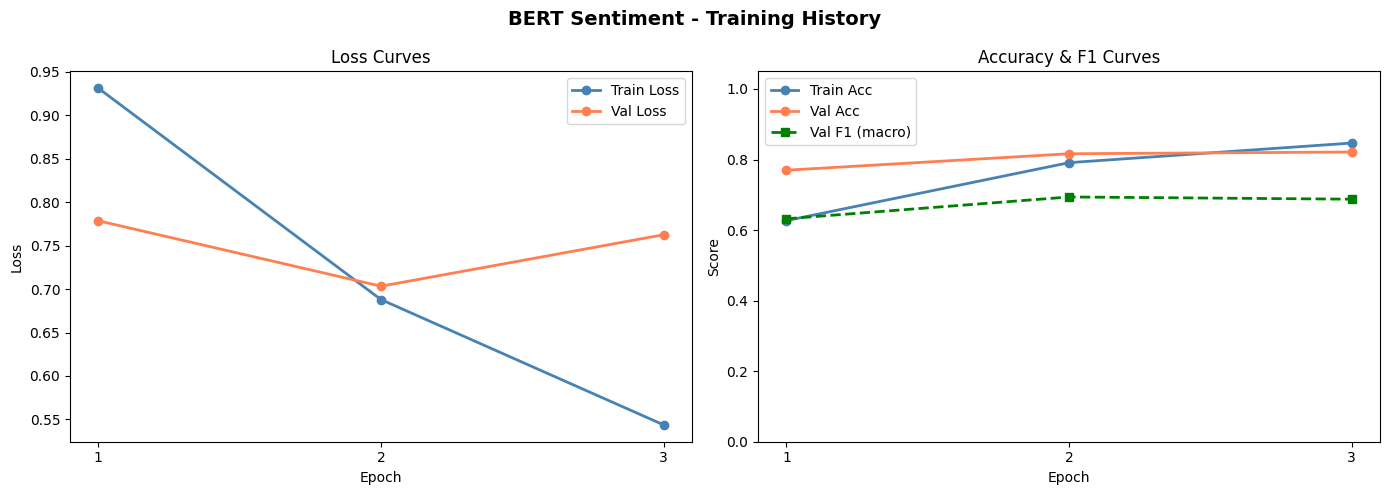

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, EPOCHS + 1)

ax1.plot(epochs_range, history["train_loss"], "o-", label="Train Loss", color="steelblue", lw=2)
ax1.plot(epochs_range, history["val_loss"],   "o-", label="Val Loss",   color="coral",     lw=2)
ax1.set(xlabel="Epoch", ylabel="Loss", title="Loss Curves")
ax1.legend(); ax1.set_xticks(list(epochs_range))

ax2.plot(epochs_range, history["train_acc"], "o-", label="Train Acc", color="steelblue", lw=2)
ax2.plot(epochs_range, history["val_acc"],   "o-", label="Val Acc",   color="coral",     lw=2)
ax2.plot(epochs_range, history["val_f1"],    "s--", label="Val F1 (macro)", color="green", lw=2)
ax2.set(xlabel="Epoch", ylabel="Score", title="Accuracy & F1 Curves")
ax2.legend(); ax2.set_xticks(list(epochs_range)); ax2.set_ylim(0, 1.05)

plt.suptitle("BERT Sentiment - Training History", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/05_training_history.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
model = BertForSequenceClassification.from_pretrained(MODEL_DIR).to(device)
model.eval()

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for ids, masks, labels in test_loader:
        ids, masks, labels = ids.to(device), masks.to(device), labels.to(device)
        logits = model(ids, attention_mask=masks).logits
        probs  = torch.softmax(logits, dim=1)
        all_preds.extend(logits.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

test_acc = accuracy_score(all_labels, all_preds)
test_f1  = f1_score(all_labels, all_preds, average="macro")

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test F1 (macro): {test_f1:.4f}")
print(classification_report(all_labels, all_preds, target_names=LABEL_NAMES, digits=4))

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Test Accuracy: 0.8170
Test F1 (macro): 0.6850
              precision    recall  f1-score   support

    negative     0.8411    0.8591    0.8500      1547
     neutral     0.3521    0.4237    0.3846       118
    positive     0.8388    0.8030    0.8205      1335

    accuracy                         0.8170      3000
   macro avg     0.6774    0.6953    0.6850      3000
weighted avg     0.8209    0.8170    0.8186      3000



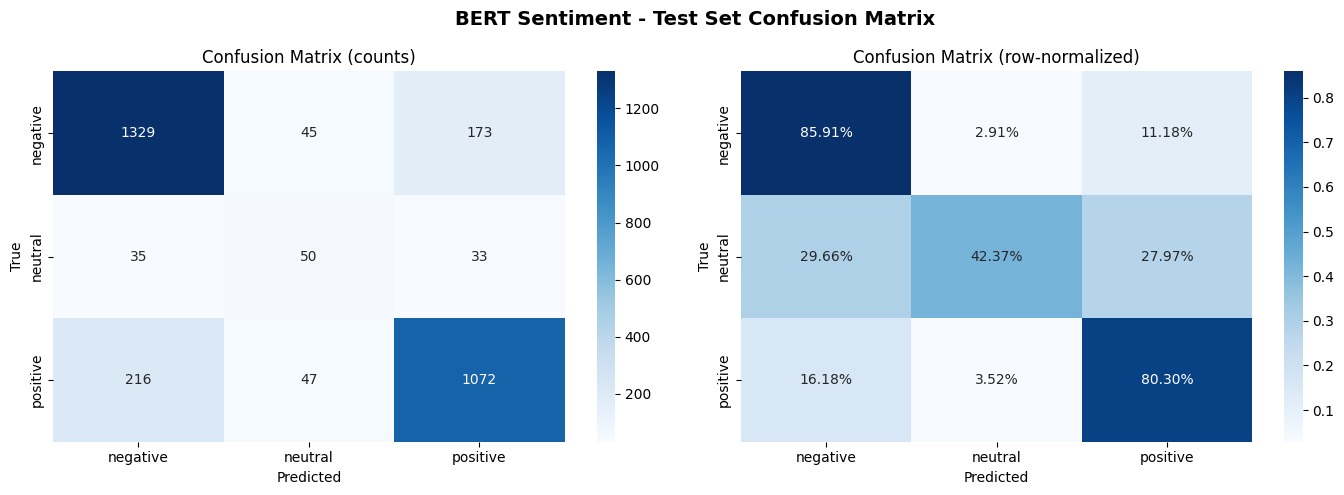

In [9]:
cm      = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=ax1)
ax1.set(xlabel="Predicted", ylabel="True", title="Confusion Matrix (counts)")

sns.heatmap(cm_norm, annot=True, fmt=".2%", cmap="Blues",
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=ax2)
ax2.set(xlabel="Predicted", ylabel="True", title="Confusion Matrix (row-normalized)")

plt.suptitle("BERT Sentiment - Test Set Confusion Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/05_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
model.save_pretrained(MODEL_DIR)
tokenizer.save_pretrained(MODEL_DIR)
print(f"Model saved: {MODEL_DIR}")

test_df = pd.DataFrame({
    "text_clean":     test_texts,
    "true_sentiment": [LABEL_NAMES[l] for l in all_labels],
    "pred_sentiment": [LABEL_NAMES[p] for p in all_preds],
    "prob_negative":  all_probs[:, 0],
    "prob_neutral":   all_probs[:, 1],
    "prob_positive":  all_probs[:, 2],
    "correct":        all_preds == all_labels,
})
test_df.to_csv(PRED_PATH, index=False)
print(f"Predictions saved: {PRED_PATH}")
print(f"Accuracy: {test_df['correct'].mean()*100:.2f}% | Rows: {len(test_df):,}")

from google.colab import files
files.download(PRED_PATH)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved: /content/drive/MyDrive/cfpb_pipeline/models/bert_sentiment
Predictions saved: /content/drive/MyDrive/cfpb_pipeline/outputs/predictions/sentiment_predictions.csv
Accuracy: 81.70% | Rows: 3,000


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>